In [75]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd


In [76]:
df = sns.load_dataset("penguins")
print(df.head())

  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  
0       3750.0    Male  
1       3800.0  Female  
2       3250.0  Female  
3          NaN     NaN  
4       3450.0  Female  


task1

<Axes: xlabel='species', ylabel='body_mass_g'>

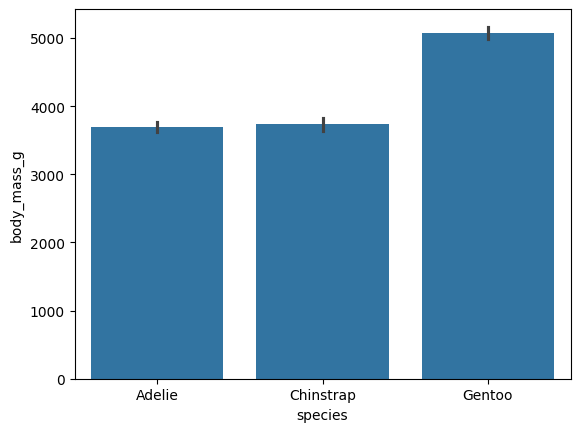

In [4]:
sns.barplot(df,x="species", y="body_mass_g")

task2

<Axes: xlabel='species', ylabel='count'>

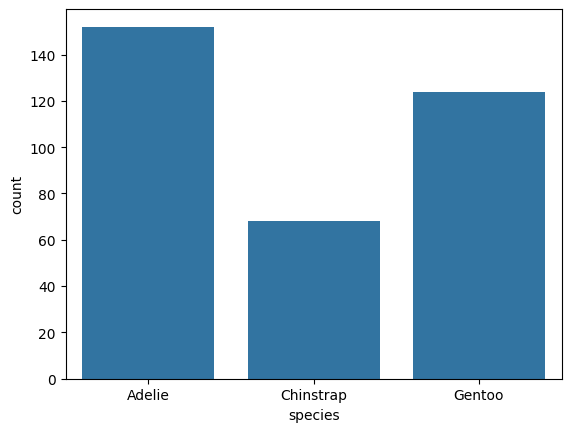

In [5]:
sns.countplot(df, x="species")

task3

<Axes: xlabel='body_mass_g', ylabel='Count'>

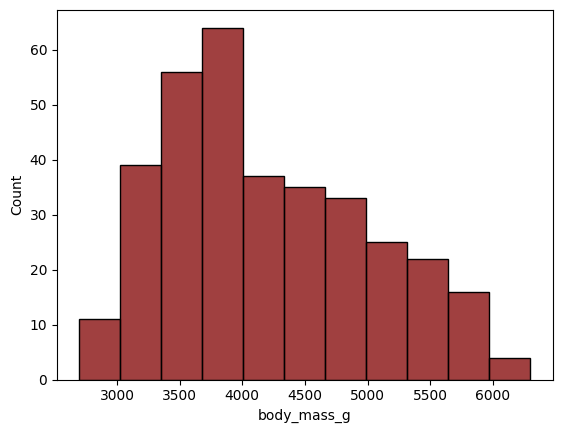

In [57]:
sns.histplot(df, x="body_mass_g",color="maroon")
#it is left skewed

task4

/tmp/ipykernel_1333/1485126232.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(df, x="species", y="body_mass_g",palette="Set1")


<Axes: xlabel='species', ylabel='body_mass_g'>

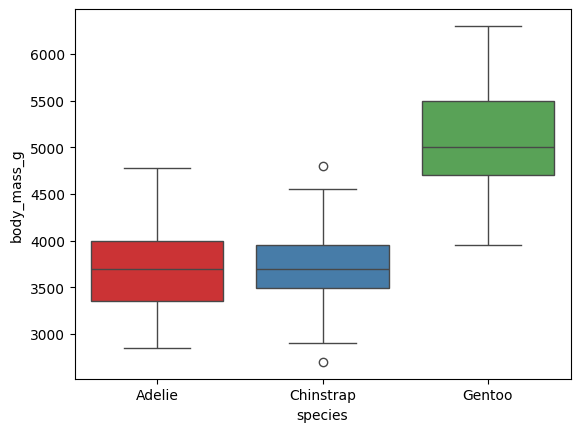

In [39]:
sns.boxplot(df, x="species", y="body_mass_g",palette="Set1")
#there are two outliers in chinstrap species

tadk5


In [46]:
Q1 = df.groupby('species')['body_mass_g'].transform('quantile', 0.25)
Q3 = df.groupby('species')['body_mass_g'].transform('quantile', 0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[(df['body_mass_g']<lower) | (df['body_mass_g'] >upper)]
print(len(outliers))
#the cpunt dpes not march because it is seeing the dataset as a whole instead of with respect to "species"

2


taask6

In [55]:
from scipy import stats
df['zscore'] = stats.zscore(df['body_mass_g'])
outliers_z = df[df['zscore'].abs() > 3]
print(len(outliers_z))
#since the data is left skewed it chnages the mean and we get different criteria for outliers

0


task7

<Axes: xlabel='bill_length_mm', ylabel='flipper_length_mm'>

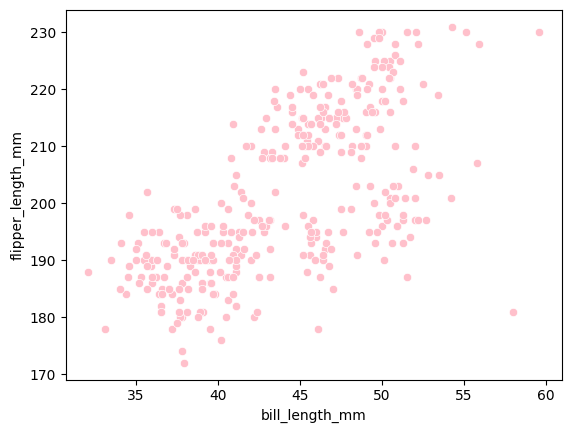

In [77]:
sns.scatterplot(df, x="bill_length_mm", y="flipper_length_mm",color="pink")
#itss a positive correlation so when bill length increaes flipper length also increases

task8

<Axes: xlabel='bill_length_mm', ylabel='body_mass_g'>

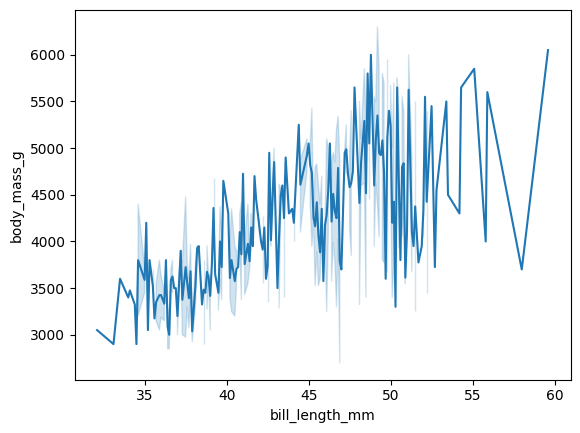

In [99]:
df['bill_length_mm']=df['bill_length_mm'].sort_values()
sns.lineplot(df, x="bill_length_mm",y="body_mass_g")

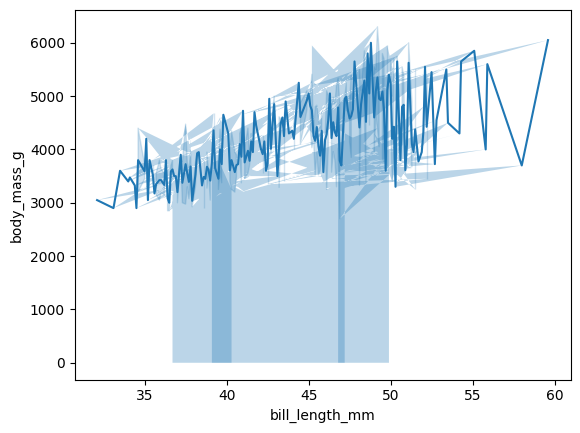

In [104]:

sns.lineplot(df, x="bill_length_mm",y="body_mass_g")
plt.fill_between(df["bill_length_mm"],df["body_mass_g"], alpha=0.3)
plt.show()

task9

(5.0, 50.0)

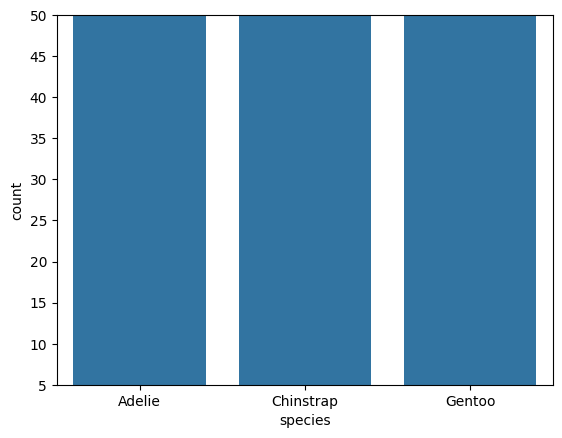

In [105]:
sns.countplot(df, x="species")
plt.ylim(5,50)
#since the x axis is truncated now, so u can cut off any values  that are not needed